In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [2]:
tab2 = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc_hertzsprung_grp.vot")

In [18]:
deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m


dist_pc2 = r_from_plx(np.array(tab2["parallax"])) # in pc
z_pc2 = dist_pc2 * np.sin(np.array(tab2["b"])*deg2rad) +14.5 #correction for height of the sun above the galactic plane
apparent_magnitude2 = np.array(tab2["phot_g_mean_mag"])
absolute_magnitude2 = apparent_magnitude2 - 5.*np.log10(dist_pc2) + 5
teff2 = np.array(tab2["teff_gspphot"]) # in K
g_rp2 = np.array(tab2["g_rp"]) # in mag

print('Anzahl Sterne gesamt: ', len(tab2))
print('Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude: ', len(tab2[np.isnan(absolute_magnitude2)]))
absmag = (absolute_magnitude2 >= 5) & (absolute_magnitude2 <= 8)
print('Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag: ', len(tab2[absmag]))
print('davon ohne Teff: ', len(tab2[absmag][np.isnan(teff2[absmag])]))
print('davon ohne z: ', len(tab2[absmag][np.isnan(z_pc2[absmag])]))
print('Insgesamt im kleineren Zylinder: ', len(dist_pc2[dist_pc2*np.cos(np.array(tab2["b"])*deg2rad)<50]))


Anzahl Sterne gesamt:  7642050
Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude:  0
Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag:  951489
davon ohne Teff:  144330
davon ohne z:  0
Insgesamt im kleineren Zylinder:  372361


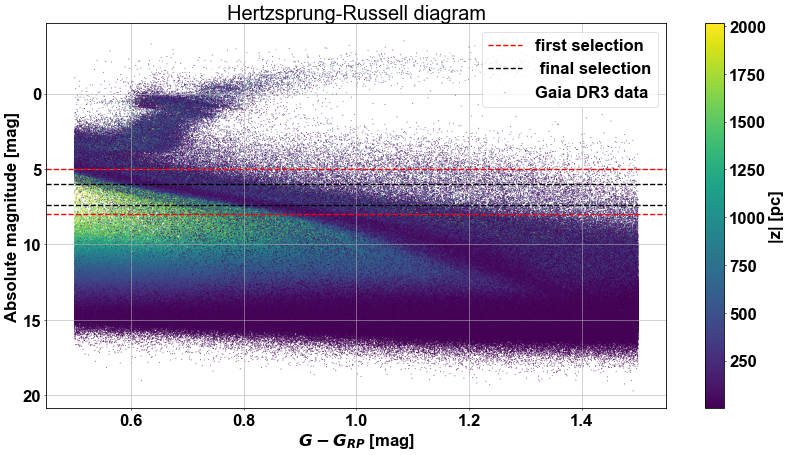

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
scatter = ax[0].scatter(g_rp2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram')
ax[0].invert_yaxis()
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
fig.set_dpi(50)
plt.show()

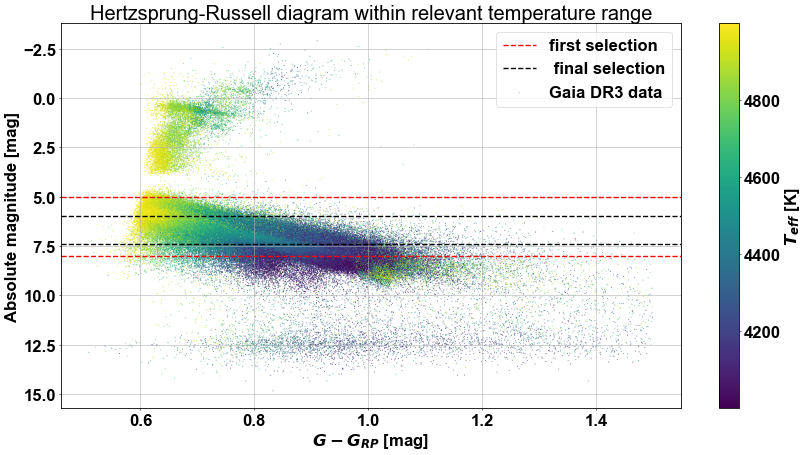

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')

scatter = ax[0].scatter(g_rp2[(teff2<5000)&(teff2>4000)], absolute_magnitude2[(teff2<5000)&(teff2>4000)], c=teff2[(teff2<5000)&(teff2>4000)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram within relevant temperature range')
ax[0].invert_yaxis()
colorbar = fig.colorbar(scatter, ax=ax, label=rf'$T_{{eff}}$ [K]')
fig.set_dpi(50)
plt.show()

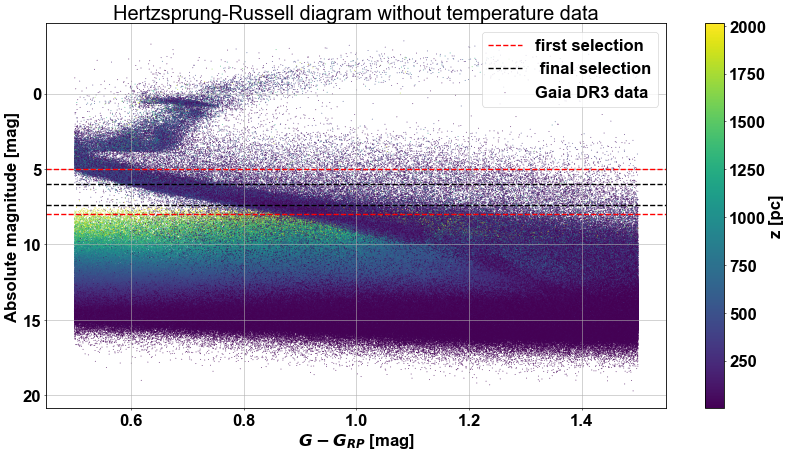

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')

scatter = ax[0].scatter(g_rp2[np.isnan(teff2)], absolute_magnitude2[np.isnan(teff2)], c=abs(z_pc2[np.isnan(teff2)]), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram without temperature data')
ax[0].invert_yaxis()
colorbar = fig.colorbar(scatter, ax=ax, label=rf'z [pc]')
fig.set_dpi(50)
plt.show()

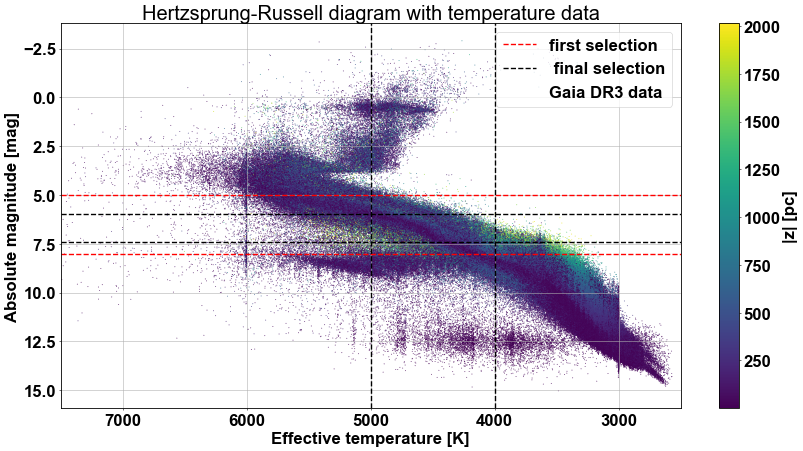

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
ax[0].axvline(x=4000, color='black', linestyle='--', linewidth=2)
ax[0].axvline(x=5000, color='black', linestyle='--', linewidth=2)

scatter = ax[0].scatter(teff2, absolute_magnitude2, c=np.abs(z_pc2), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel('Effective temperature [K]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram with temperature data')
ax[0].invert_yaxis()
ax[0].invert_xaxis()
ax[0].set_xlim(7500, 2500)
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
fig.set_dpi(50)
plt.show()

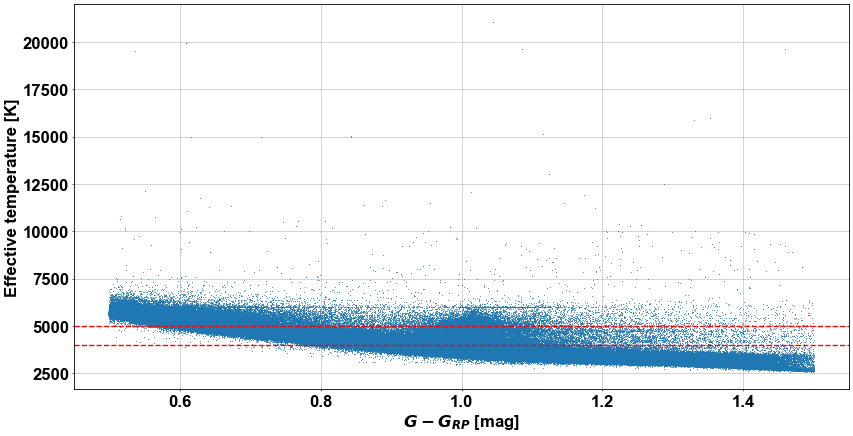

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot(g_rp2, teff2, '.', markersize=1, label='Gaia DR3 data')
plt.axhline(y=5000, color='r', linestyle='--', linewidth=2)
plt.axhline(y=4000, color='r', linestyle='--', linewidth=2)
ax.set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax.set_ylabel('Effective temperature [K]')
plt.grid(which='both')
fig.set_dpi(50)
plt.show()

In [9]:
a = (absolute_magnitude2>=6)&(absolute_magnitude2<=7.4)
g_large = (g_rp2[a]>=0.6) & (g_rp2[a]<=1.1)
g_small = (g_rp2[a]>=0.77) & (g_rp2[a]<=0.83)
t = (teff2[a]>=4000) & (teff2[a]<=5000)

n1, bins1 = np.histogram(z_pc2[a][g_large], bins=40)
n2, bins2 = np.histogram(z_pc2[a][g_small], bins=40)

n3, bins3 = np.histogram(z_pc2[a][g_large][~np.isnan(teff2[a][g_large])], bins=40)
n4, bins4 = np.histogram(z_pc2[a][g_small][~np.isnan(teff2[a][g_small])], bins=40)

n5, bins5 = np.histogram(z_pc2[a][t], bins=40,)
n6, bins6 = np.histogram(z_pc2[a][g_large&t], bins=40)
n7, bins7 = np.histogram(z_pc2[a][g_small&t], bins=40)

n8, bins8 = np.histogram(z_pc2[a][g_large][np.isnan(teff2[a][g_large])], bins=40)
n9, bins9 = np.histogram(z_pc2[a][g_small][np.isnan(teff2[a][g_small])], bins=40)

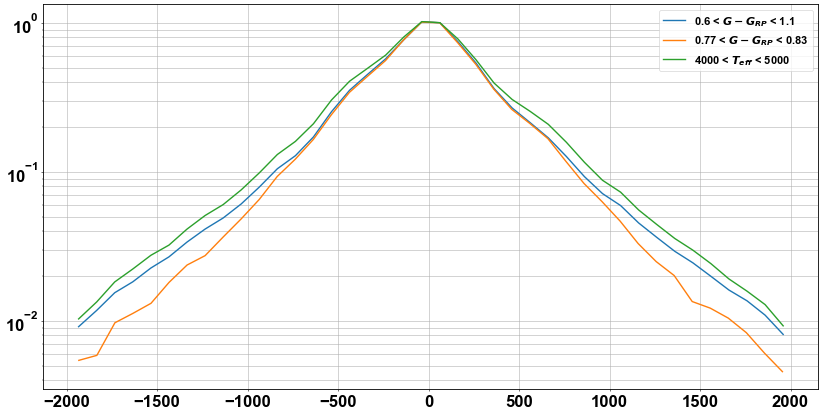

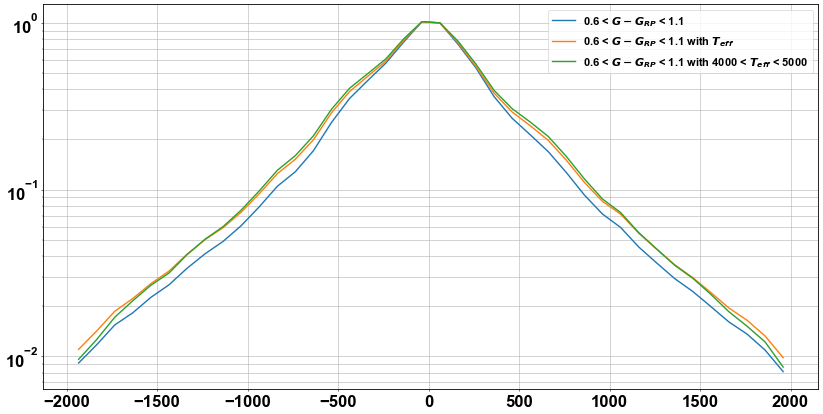

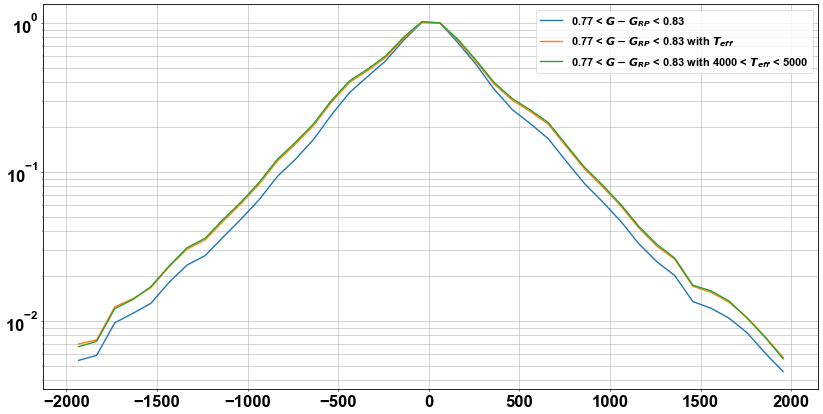

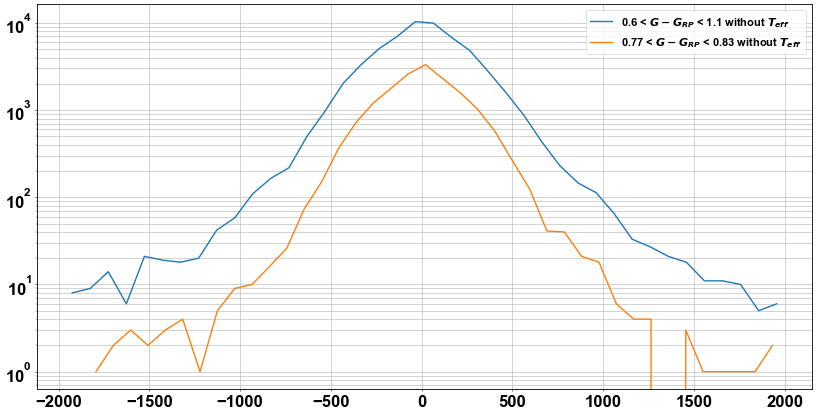

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins1[:-1]+bins1[1:])/2, n1/n1[20], label='0.6 < $G-G_{RP}$ < 1.1')
ax.plot((bins2[:-1]+bins2[1:])/2, n2/n2[20], label='0.77 < $G-G_{RP}$ < 0.83')
ax.plot((bins5[:-1]+bins5[1:])/2, n5/n5[20], label='4000 < $T_{eff}$ < 5000')
ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins1[:-1]+bins1[1:])/2, n1/n1[20], label='0.6 < $G-G_{RP}$ < 1.1')
ax.plot((bins3[:-1]+bins3[1:])/2, n3/n3[20], label='0.6 < $G-G_{RP}$ < 1.1 with $T_{eff}$')
ax.plot((bins6[:-1]+bins6[1:])/2, n6/n6[20], label='0.6 < $G-G_{RP}$ < 1.1 with 4000 < $T_{eff}$ < 5000')
ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins2[:-1]+bins2[1:])/2, n2/n2[20], label='0.77 < $G-G_{RP}$ < 0.83')
ax.plot((bins4[:-1]+bins4[1:])/2, n4/n4[20], label='0.77 < $G-G_{RP}$ < 0.83 with $T_{eff}$')
ax.plot((bins7[:-1]+bins7[1:])/2, n7/n7[20], label='0.77 < $G-G_{RP}$ < 0.83 with 4000 < $T_{eff}$ < 5000')
ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot((bins8[:-1]+bins8[1:])/2, n8, label='0.6 < $G-G_{RP}$ < 1.1 without $T_{eff}$')
ax.plot((bins9[:-1]+bins9[1:])/2, n9, label='0.77 < $G-G_{RP}$ < 0.83 without $T_{eff}$')
ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()

C:\Users\Ruben\AppData\Local\Temp\ipykernel_86484\3117530852.py:9: RuntimeWarning: divide by zero encountered in log10
  m = M + 5.*np.log10(d) - 5.


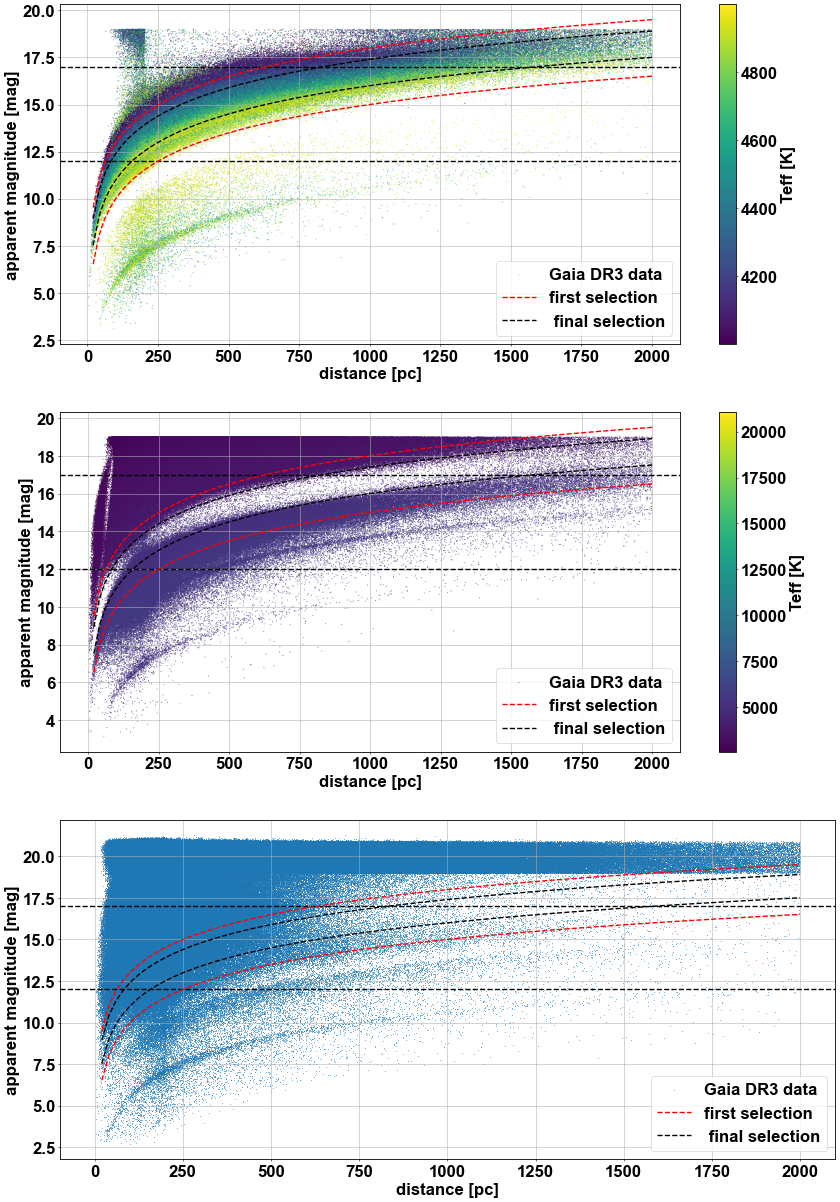

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(20, 30))
ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)
where = np.where((teff2>4000) & (teff2<5000))
scatter = ax[0].scatter(np.abs(dist_pc2[where]), apparent_magnitude2[where], c=teff2[where], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')
z = np.linspace(0, 2000, 100)
ax[0].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[0].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[0].plot(z, M_d_to_m(7.4, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[0].grid()
ax[0].legend(loc='lower right')

ax[0].set_ylabel('apparent magnitude [mag]')
ax[0].set_xlabel('distance [pc]')
colorbar = fig.colorbar(scatter, ax=ax[0], label='Teff [K]')

ax[1].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[1].axhline(y=12, color='black', linestyle='--', linewidth=2)
where2 = np.where((teff2<=4000) | (teff2>=5000))
scatter2 = ax[1].scatter(np.abs(dist_pc2[where2]), apparent_magnitude2[where2], c=teff2[where2], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')
z = np.linspace(0, 2000, 100)
ax[1].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[1].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[1].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[1].plot(z, M_d_to_m(7.4, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[1].grid()
ax[1].legend(loc='lower right')

ax[1].set_ylabel('apparent magnitude [mag]')
ax[1].set_xlabel('distance [pc]')
colorbar2 = fig.colorbar(scatter2, ax=ax[1], label='Teff [K]')

ax[2].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[2].axhline(y=12, color='black', linestyle='--', linewidth=2)

scatter3 = ax[2].scatter(np.abs(dist_pc2[np.isnan(teff2)]), apparent_magnitude2[np.isnan(teff2)], marker='.', s=0.5, label='Gaia DR3 data')
z = np.linspace(0, 2000, 100)
ax[2].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[2].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[2].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[2].plot(z, M_d_to_m(7.4, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[2].grid()
ax[2].legend(loc='lower right')

ax[2].set_ylabel('apparent magnitude [mag]')
ax[2].set_xlabel('distance [pc]')

fig.set_dpi(50)
plt.show()